In [1]:
import sys
import numpy as np
import cv2
from matplotlib import pyplot as plt
sys.path.append('../robot')
from common import arena
from common.poses import Poses
from observation_models.distance import DistanceObservationModel

In [2]:
low_probability = 0.1
# Ranges for world x and y coordinates, indexed by map coordinates
map_frame = arena.MapFrame(100)

In [3]:
def plot_map(map_data, axs=None):
    if axs is None:
        plt.figure(figsize=(8, 8))    
        axs = plt
    axs.imshow(
        map_data,
        cmap='gray_r',
        origin='lower',
        extent=[map_frame.w_left, map_frame.w_right, map_frame.w_bottom, map_frame.w_top],
        aspect='equal'
    )

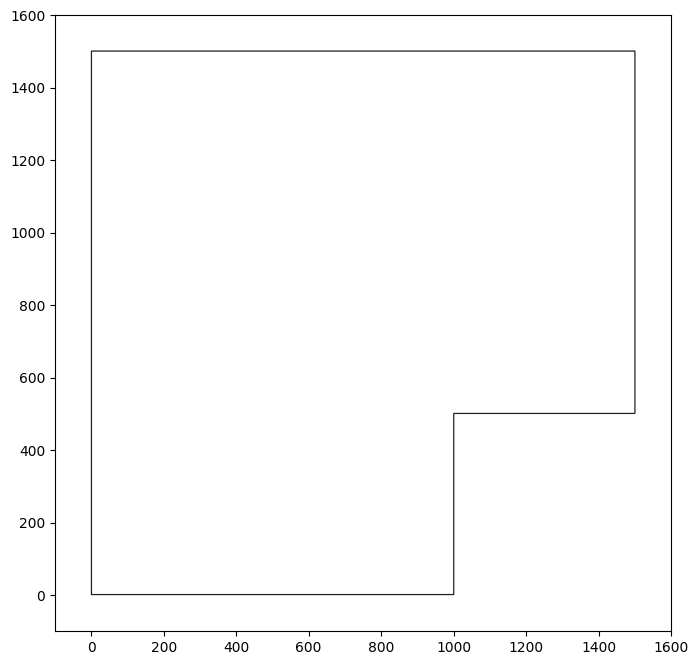

In [4]:
walls_map = np.zeros((map_frame.height, map_frame.width), dtype=np.float32)
cv2.polylines(walls_map, 
              map_frame.world_to_map(np.array([arena.walls])), 
              isClosed=True, color=1.0, thickness=2)

plot_map(walls_map)

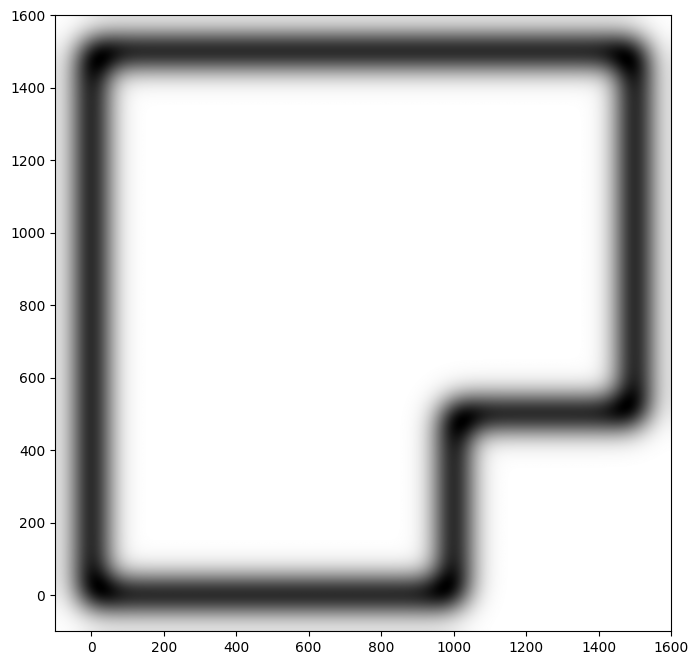

In [5]:
distance_map = cv2.GaussianBlur(walls_map, (0, 0), 45)
plot_map(distance_map)

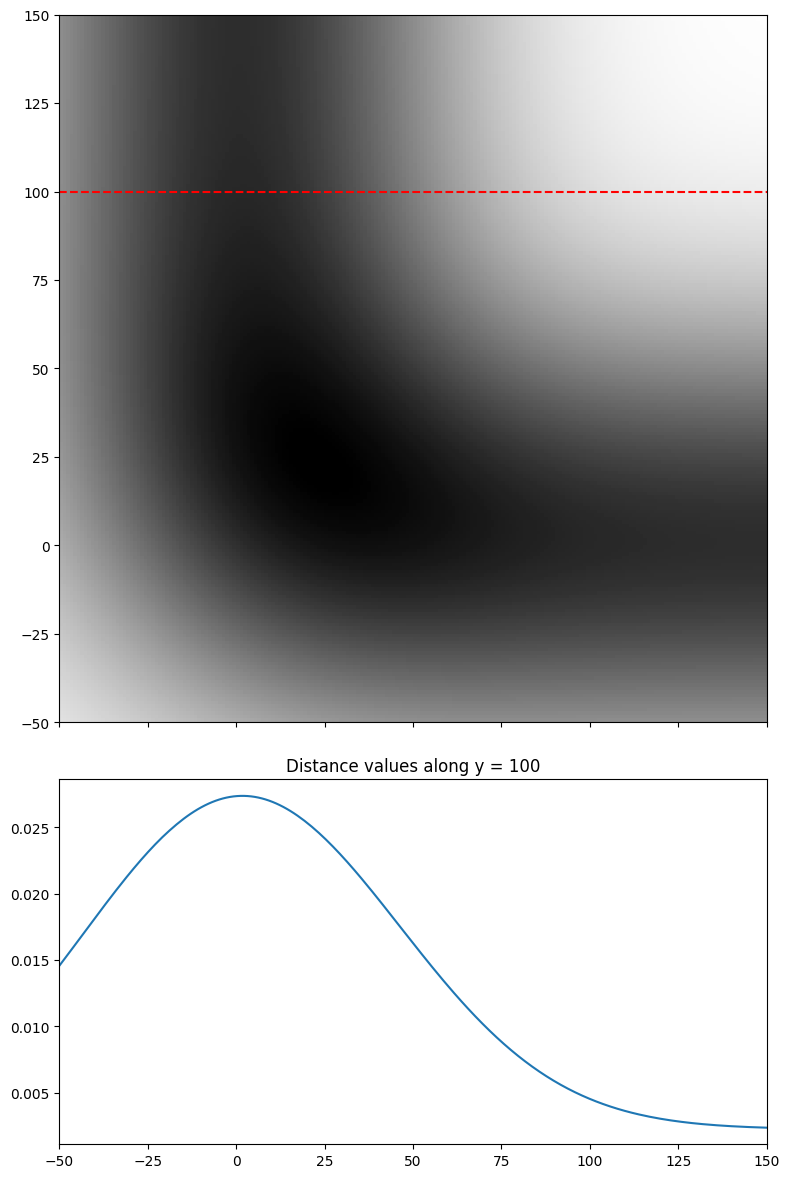

In [6]:
# Plot map and sampled row in a vertical stack with aligned x-axes
fig, (ax_map, ax_row) = plt.subplots(
    2, 1, figsize=(8, 12), sharex=True,
    gridspec_kw={"height_ratios": [4, 2]}
 )

# Top plot: distance map with sampling line
plot_map(distance_map, axs=ax_map)
ax_map.set_xlim(-50, 150)
ax_map.set_ylim(-50, 150)
ax_map.axhline(y=100, color='r', linestyle='--')
ax_map.tick_params(labelbottom=False)

# Bottom plot: values along y=100 (projection of the dashed line above)
map_y = 100 + map_frame.margin
row = distance_map[map_y, 50:250]
ax_row.plot(np.linspace(-50, 150, 200), row)
ax_row.set_title('Distance values along y = 100')
ax_row.set_xlim(-50, 150)

fig.tight_layout()

In [7]:
np.min(distance_map), np.max(distance_map)

(np.float32(0.0), np.float32(0.032393876))

(np.float32(0.1), np.float32(1.0))

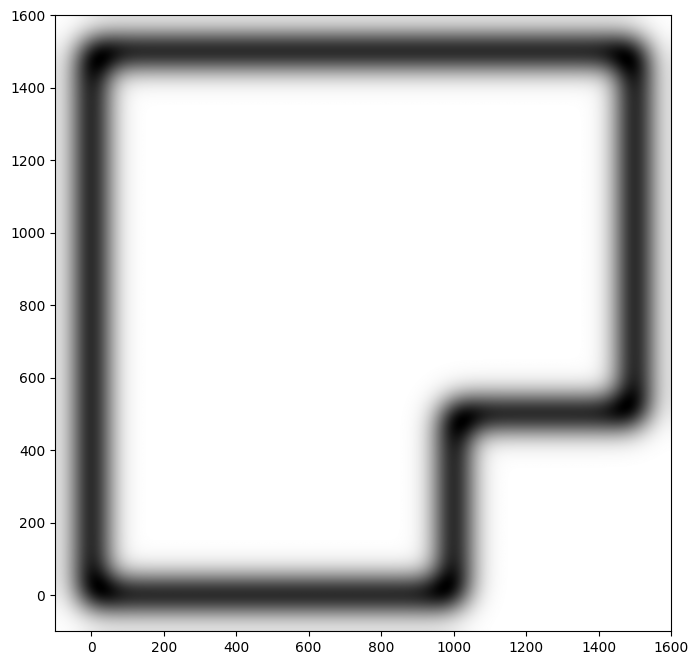

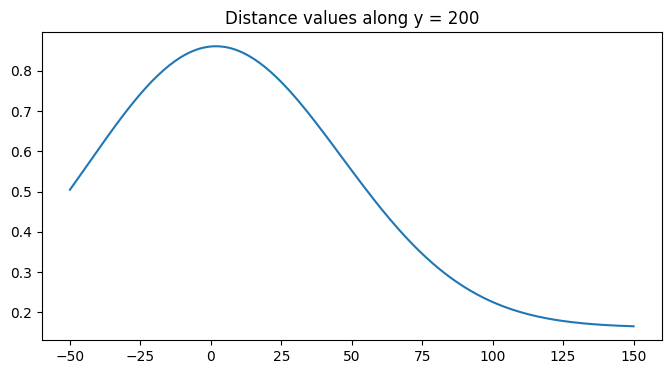

In [8]:
normalized_map = cv2.normalize(distance_map, None, alpha=low_probability, beta=1.0, norm_type=cv2.NORM_MINMAX)
plot_map(normalized_map)

row = normalized_map[map_y, 50:250]
plt.figure(figsize=(8, 4))
plt.plot(np.linspace(-50, 150, 200), row)
plt.title(f'Distance values along y = {map_y}')
np.min(normalized_map), np.max(normalized_map)

In [9]:
np.save('../robot/observation_models/distance_map.npy', normalized_map)

In [10]:
model = DistanceObservationModel("../robot/observation_models/distance_map.npy")
world_positions = np.array([[0, 0], [1705, 1500], [1500, 1200], [400, 400]])
model.get_probabilities(world_positions)

array([0.83666176, 0.1       , 0.83884484, 0.1       ])

In [11]:
distance_readings = np.array([[50]*8] * 4 + [[223,205,192,182,174,169,165,163]] * 4)

distance_readings[5, 3] = 3000

In [12]:
model.handle_sensor_readings(distance_readings)
model.relative_sensor_positions

array([[256.02513575, -85.33840542],
       [246.988051  , -56.75127984],
       [239.28723556, -32.16119487],
       [231.71368033, -10.2048214 ],
       [223.72626581,   9.75625782],
       [216.61220213,  28.30855174],
       [208.55135812,  45.67785939],
       [200.5923638 ,  62.37739948]])

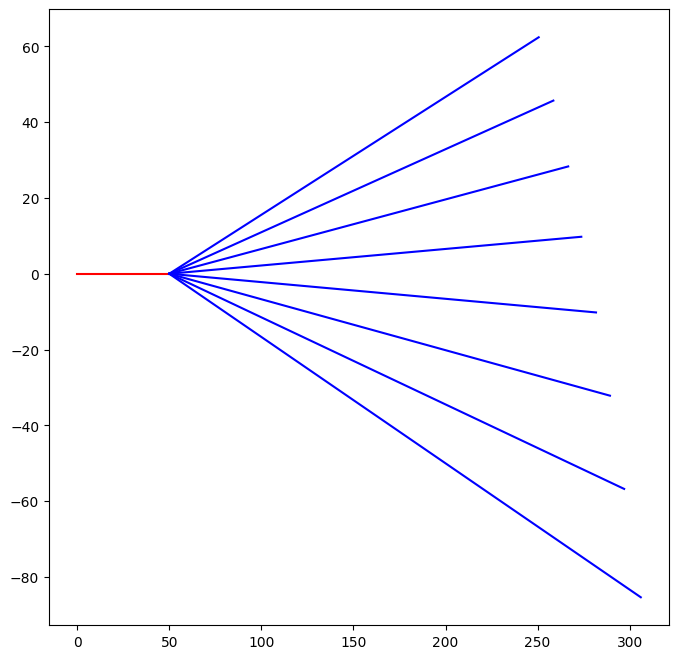

In [14]:
# Draw from the origin to the model forward offset
plt.figure(figsize=(8, 8))
plt.plot([0, model.sensor_forward_offset], [0, 0], 'r-')
# Draw the sensor positions relative to the forward offset
for sensor_pos in model.relative_sensor_positions:
    plt.plot([model.sensor_forward_offset, model.sensor_forward_offset + sensor_pos[0]], 
             [0, sensor_pos[1]], 'b-')

In [39]:
poses = Poses.generate(20, (0, 1500), (0, 1500), (0, 2 * np.pi))
poses

Poses([( 459.3651 , 1230.4352 , 2.7808948 ),
       (1085.8856 ,  472.41257, 5.6170545 ),
       (1369.3229 ,  340.8834 , 5.1651964 ),
       (1013.16504,  163.48053, 5.153469  ),
       (1287.487  ,  891.64105, 3.703837  ),
       (1118.4128 ,  483.56448, 1.4347919 ),
       (1226.4728 ,  947.25867, 2.726663  ),
       ( 791.58057,  901.89105, 2.772184  ),
       (1122.2644 ,  494.79303, 5.28336   ),
       (1477.591  , 1022.47174, 3.729331  ),
       ( 646.4051 ,  390.38654, 0.89701474),
       ( 358.3024 ,  185.67061, 4.001954  ),
       ( 546.8793 , 1060.3467 , 0.42145357),
       ( 888.35284,  458.43542, 2.1742113 ),
       (1257.1936 , 1211.4326 , 0.52102405),
       (1185.3488 , 1080.145  , 4.7851267 ),
       ( 482.5995 ,  176.54082, 2.4526036 ),
       ( 688.9471 ,  776.3849 , 3.759394  ),
       (1020.9508 ,  792.47217, 5.9758763 ),
       (1367.8522 , 1330.2723 , 1.9216644 )],
      dtype=[('x', '<f4'), ('y', '<f4'), ('theta', '<f4')])

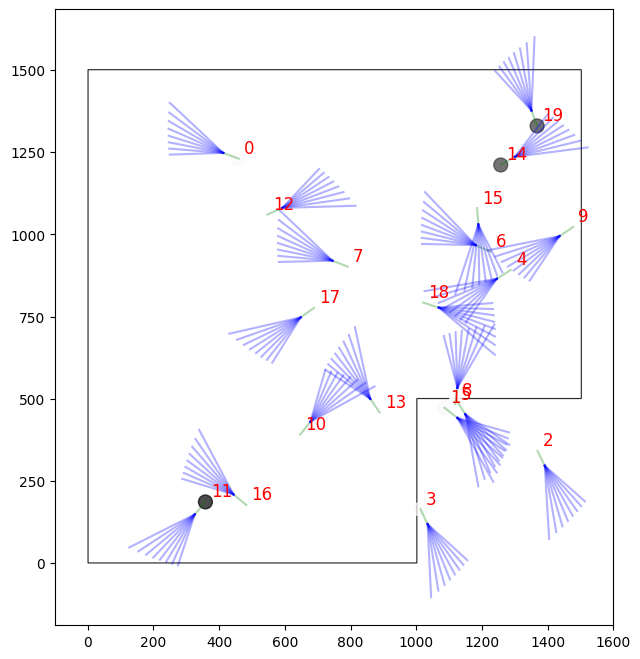

In [40]:
endpoints = model.sensor_endpoints(poses)
weights = model.calculate_weights(poses)
plot_map(walls_map)
for n, pose in enumerate(poses):
    x, y, theta = pose
    offset_x = x + model.sensor_forward_offset * np.cos(theta)
    offset_y = y + model.sensor_forward_offset * np.sin(theta)
    plt.plot([x, offset_x], [y, offset_y], 'g-', alpha=0.3)
    for sensor in range(8):
        plt.plot([offset_x, endpoints[n, sensor, 0]], 
                 [offset_y, endpoints[n, sensor, 1]], 'b-', alpha=0.3)
    # Add a label for n near the pose 
    plt.text(x + 16, y + 16, str(n), color='red', fontsize=12)
    
# Draw a scatter on the poses, such that it's a greyscale cmap based on the weight
plt.scatter(poses['x'], poses['y'], c=np.log(weights), cmap='Greys', s=100, alpha=0.7)


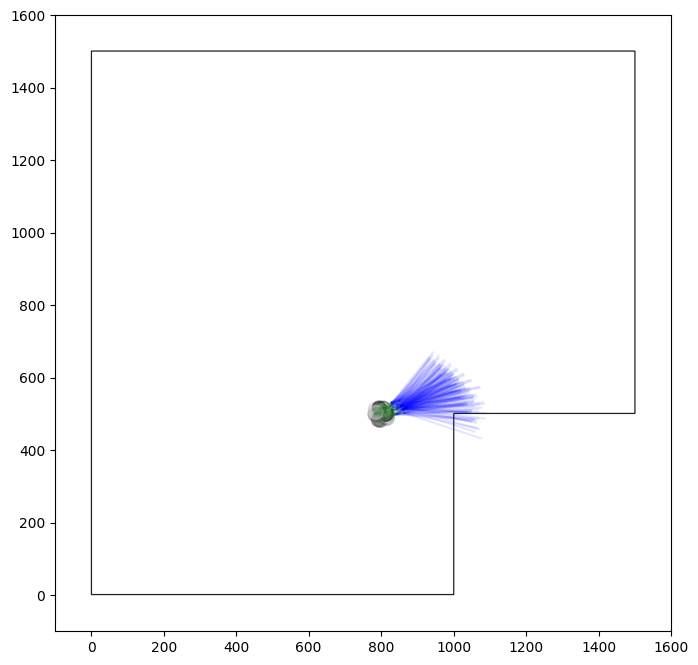

In [41]:
# Generate a more limited set of poses around a similar position
close_poses = Poses.generate(20, (780, 820), (480, 520), (0, 0.2 * np.pi))
close_endpoints = model.sensor_endpoints(close_poses)
close_weights = model.calculate_weights(close_poses)
plot_map(walls_map)
for n, pose in enumerate(close_poses):
    x, y, theta = pose
    offset_x = x + model.sensor_forward_offset * np.cos(theta)
    offset_y = y + model.sensor_forward_offset * np.sin(theta)
    plt.plot([x, offset_x], [y, offset_y], 'g-', alpha=0.2)
    for sensor in range(8):
        plt.plot([offset_x, close_endpoints[n, sensor, 0]], 
                 [offset_y, close_endpoints[n, sensor, 1]], 'b-', alpha=0.1)
    
# Draw a scatter on the poses, such that it's a greyscale cmap based on the weight
plt.scatter(close_poses['x'], close_poses['y'], c=np.log(close_weights), cmap='Greys', s=100, alpha=0.4)

In [50]:
# Geometric diversity only (x, y, theta) with one shared normalization scale

global_x_range = (arena.left, arena.right)
global_y_range = (arena.bottom, arena.top)

# Max possible std for bounded values in [lo, hi]
max_std_x = (global_x_range[1] - global_x_range[0]) / 2.0
max_std_y = (global_y_range[1] - global_y_range[0]) / 2.0


def geometric_diversity_score(label, poses):
    x_norm = np.clip(np.std(poses['x']) / max_std_x, 0.0, 1.0)
    y_norm = np.clip(np.std(poses['y']) / max_std_y, 0.0, 1.0)

    # Circular spread in [0, 1]: 0=single heading, 1=maximally spread headings
    theta = poses['theta']
    theta_norm = np.clip(1.0 - np.hypot(np.mean(np.cos(theta)), np.mean(np.sin(theta))), 0.0, 1.0)

    components = np.array([x_norm, y_norm, theta_norm], dtype=float)
    overall = np.mean(components)

    print(f"--- {label} ---")
    print(f"x_norm={x_norm:.3f}, y_norm={y_norm:.3f}, theta_norm={theta_norm:.3f}")
    print(f"Geometric diversity score: {overall:.3f}")
    print()


geometric_diversity_score("All poses", poses)
geometric_diversity_score("Close poses", close_poses)

--- All poses ---
x_norm=0.443, y_norm=0.491, theta_norm=0.899
Geometric diversity score: 0.611

--- Close poses ---
x_norm=0.016, y_norm=0.013, theta_norm=0.012
Geometric diversity score: 0.014

